In [30]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

import pymc as pm
import pytensor.tensor as pt
import numpy as np
import arviz as az
import arviz_plots as azp
from scipy.signal import periodogram


In [3]:
sunspot_data = sm.datasets.sunspots.load_pandas().data
sunspot_data.head()

,YEAR,SUNACTIVITY
0,1700.0,5.0
1,1701.0,11.0
2,1702.0,16.0
3,1703.0,23.0
4,1704.0,36.0


In [4]:
year = sunspot_data["YEAR"].values
activity = sunspot_data["SUNACTIVITY"].values
n = len(activity)

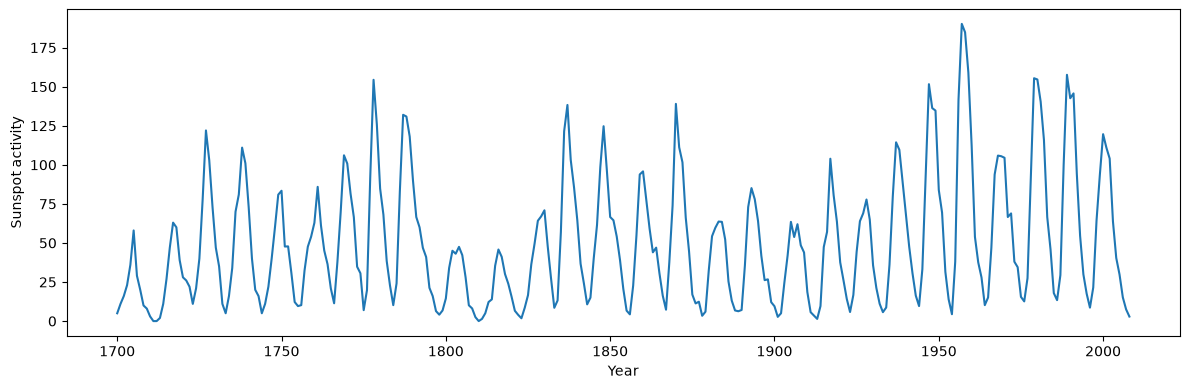

n = 309, 期間：　1700.0~2008.0
n = 309, 黒点の数：　0.0~190.2


In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(year, activity)
ax.set_xlabel("Year")
ax.set_ylabel("Sunspot activity")
plt.tight_layout()
plt.show()

print(f"n = {n}, 期間：　{year.min()}~{year.max()}")
print(f"n = {n}, 黒点の数：　{activity.min()}~{activity.max()}")

In [20]:
t = np.arange(n)

with pm.Model() as model_sunspot_v0:
    mu = pm.Normal("mu", mu=activity.mean(), sigma=activity.std())
    A = pm.HalfNormal("A", sigma=activity.std())
    T = pm.Normal("T", mu=11, sigma=2)
    phi = pm.Uniform("phi", lower=-np.pi, upper=np.pi)

    sigma_obs = pm.HalfNormal("sigma_obs", sigma=activity.std())

    mean_signal = mu + A * pm.math.sin((2 * np.pi * t) / T + phi)  

    obs = pm.TruncatedNormal(
    "obs", mu=mean_signal, sigma=sigma_obs, lower=0, observed=activity
    )
    trace_sunspot_v0 = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, A, T, phi, sigma_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 6 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [21]:
az.summary(trace_sunspot_v0, var_names=["mu", "A", "T", "phi", "sigma_obs"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,3,13,-18,21,44,132,1.06,1.7,1.6
A,62,10,47,78,34,162,1.08,1.7,1.3
T,10.4,0.4,10,11,5,10,2.10,0.19,0.079
phi,-2.4,0.6,-3.1,-1.4,5,14,1.91,0.31,0.099
sigma_obs,56,6,47,66,14,20,1.20,1.5,1.1


In [22]:
n_divergent = trace_sunspot_v0.sample_stats.diverging.sum().item()
print(f"Divergence: {n_divergent}")

Divergence: 0


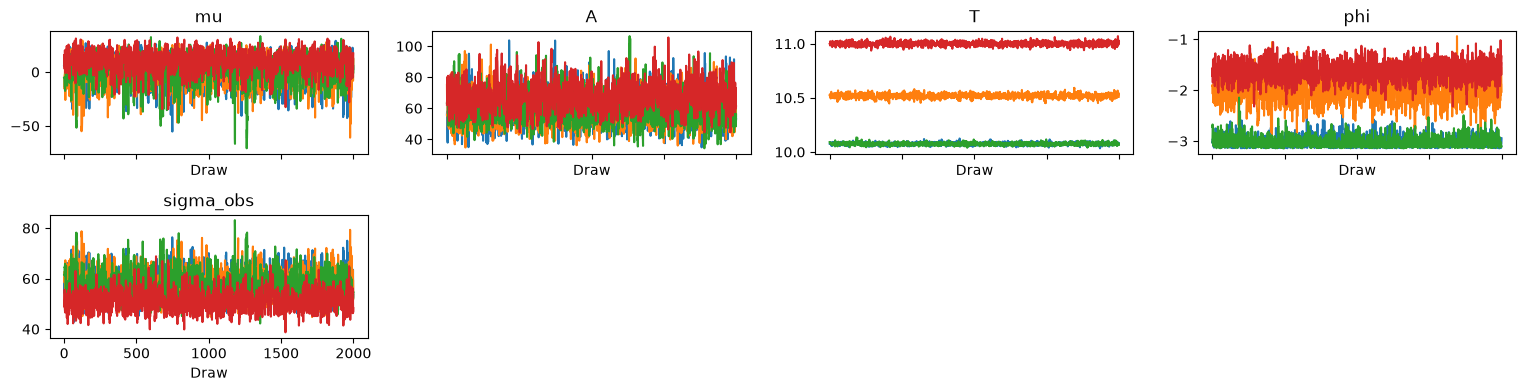

In [24]:
az.plot_trace(trace_sunspot_v0, var_names=["mu", "A", "T", "phi", "sigma_obs"])
plt.tight_layout()
plt.show()

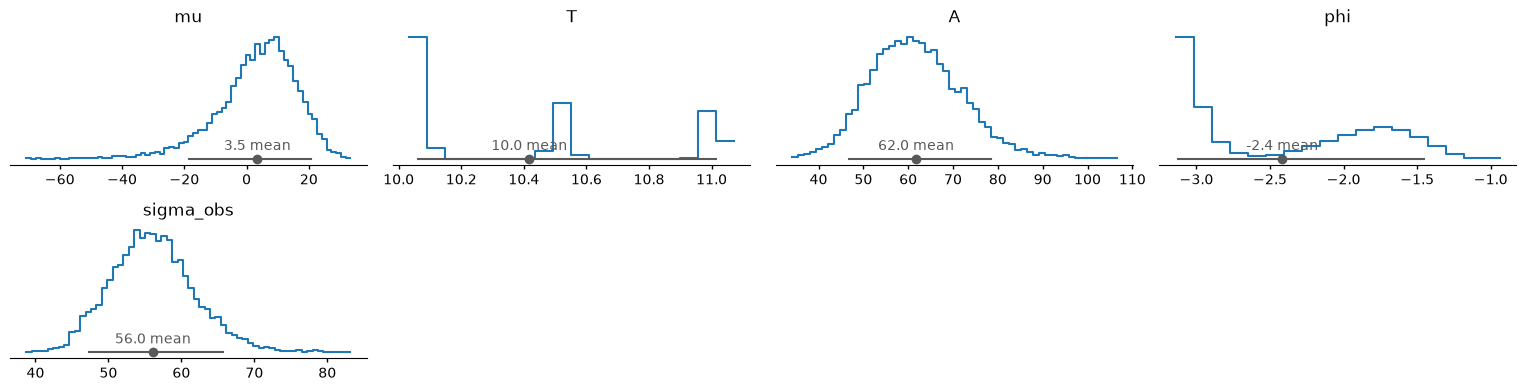

In [26]:
azp.plot_dist(trace_sunspot_v0, kind="hist")
plt.tight_layout()
plt.show()

In [32]:
#事前にFFT/周期図(periodogram)で周期を特定してから固定・制約する
freqs, power = periodogram(activity - activity.mean())
periods = 1 / freqs[1:]
dominant_period = periods[np.argmax(power[1:])]
print(f"支配的な周期: {dominant_period:.2f}年")

支配的な周期: 11.04年


周期: 11.04年, パワー: 135012.9
周期: 9.97年, パワー: 71820.4
周期: 10.66年, パワー: 45607.1
周期: 103.00年, パワー: 43837.8
周期: 11.88年, パワー: 32887.6

支配的な周期: 11.04年


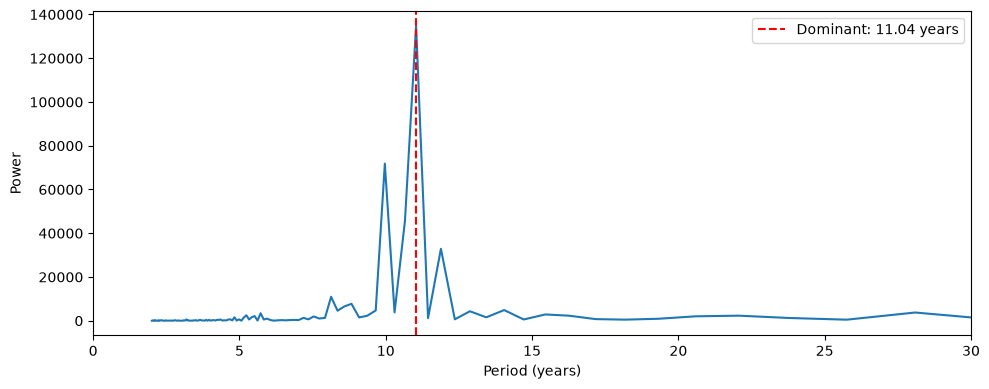

In [35]:
# 平均を引いてから周期図を計算(トレンド・オフセットの影響を除く)
freqs, power = periodogram(activity - activity.mean())

# 周波数0(直流成分)を除外して、周期に変換
freqs_nonzero = freqs[1:]
power_nonzero = power[1:]
periods = 1 / freqs_nonzero

# パワーが大きい順にトップ5の周期を確認
top_idx = np.argsort(power_nonzero)[::-1][:5]
for i in top_idx:
    print(f"周期: {periods[i]:.2f}年, パワー: {power_nonzero[i]:.1f}")

dominant_period = periods[np.argmax(power_nonzero)]
print(f"\n支配的な周期: {dominant_period:.2f}年")

# 可視化
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(periods, power_nonzero)
ax.set_xlim(0, 30)  # 30年以下の周期に絞って見やすく
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power")
ax.axvline(dominant_period, color="red", linestyle="--", 
           label=f"Dominant: {dominant_period:.2f} years")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
t = np.arange(n)

with pm.Model() as model_sunspot_v1:
    mu = pm.Normal("mu", mu=activity.mean(), sigma=activity.std())
    A = pm.HalfNormal("A", sigma=activity.std())
    T = pm.Normal("T", mu=dominant_period, sigma=0.3)
    phi = pm.Uniform("phi", lower=-np.pi, upper=np.pi)

    sigma_obs = pm.HalfNormal("sigma_obs", sigma=activity.std())

    mean_signal = mu + A * pm.math.sin((2 * np.pi * t) / T + phi)  

    obs = pm.TruncatedNormal(
    "obs", mu=mean_signal, sigma=sigma_obs, lower=0, observed=activity
    )
    trace_sunspot_v1 = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, A, T, phi, sigma_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 6 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [36]:
#Tの周期を10～11年の間に絞っても変わらなかった
az.summary(trace_sunspot_v1, var_names=["mu", "A", "T", "phi", "sigma_obs"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,3,13,-19,21,35,121,1.08,2,1.6
A,62,10,46,78,41,233,1.07,1.6,1.1
T,10.5,0.3,10,11,4,10,2.41,0.16,0.082
phi,-2.1,0.6,-3.1,-1.4,5,10,1.79,0.26,0.13
sigma_obs,56,6,47,66,12,19,1.24,1.6,1.1


In [40]:
#振動固定モデル
t = np.arange(n)

with pm.Model() as model_sunspot_v2:
    mu = pm.Normal("mu", mu=activity.mean(), sigma=activity.std())
    
    T_fixed = dominant_period
    omega = 2 * np.pi / T_fixed
    

    beta1 = pm.Normal("beta1", mu=0, sigma=activity.std())
    beta2 = pm.Normal("beta2", mu=0, sigma=activity.std())

    sigma_obs = pm.HalfNormal("sigma_obs", sigma=activity.std())

    mean_signal = mu + beta1 * pm.math.sin(omega * t) + beta2 * pm.math.cos(omega * t)  

    obs = pm.TruncatedNormal(
    "obs", mu=mean_signal, sigma=sigma_obs, lower=0, observed=activity
    )
    A = pm.Deterministic("A", pm.math.sqrt(beta1 ** 2 + beta2 ** 2))
    phi = pm.Deterministic("phi", pt.arctan2(beta2, beta1))
    trace_sunspot_v2 = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, beta1, beta2, sigma_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


In [44]:
az.summary(trace_sunspot_v2, var_names=["mu", "beta1", "beta2", "sigma_obs", "A", "phi"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,8.3,10,-9,22,2564,3116,1.00,0.2,0.17
beta1,18.6,6.7,8.3,30,4402,3932,1.00,0.1,0.073
beta2,-65.7,9,-81,-52,2887,3629,1.00,0.17,0.13
sigma_obs,51.8,4.2,46,59,2671,3415,1.00,0.082,0.065
A,68.5,9.2,55,84,2747,3633,1.00,0.18,0.14
phi,-1.295,0.093,-1.4,-1.1,5324,4763,1.00,0.0013,0.00091


In [46]:
A_mean = trace_sunspot_v2.posterior["A"].mean().item()
phi_mean = trace_sunspot_v2.posterior["phi"].mean().item()
print(f"振幅 A ≈ {A_mean:.1f}")
print(f"位相 φ ≈ {phi_mean:.2f} rad")


振幅 A ≈ 68.5
位相 φ ≈ -1.29 rad


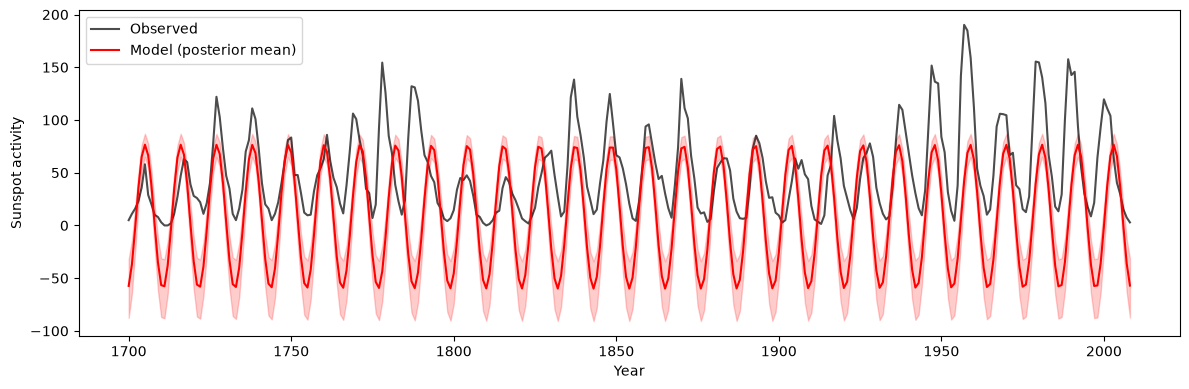

In [47]:
#サンプリングは完璧に健全化したが、モデルの表現力に限界が見られる（黒点の数の非負制限）
mean_signal_post = (
    trace_sunspot_v2.posterior["mu"].values.reshape(-1, 1)
    + trace_sunspot_v2.posterior["beta1"].values.reshape(-1, 1) * np.sin(omega * t)
    + trace_sunspot_v2.posterior["beta2"].values.reshape(-1, 1) * np.cos(omega * t)
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(year, activity, color="black", label="Observed", alpha=0.7)
ax.plot(year, mean_signal_post.mean(axis=0), color="red", label="Model (posterior mean)")
ax.fill_between(
    year,
    np.percentile(mean_signal_post, 5.5, axis=0),
    np.percentile(mean_signal_post, 94.5, axis=0),
    color="red", alpha=0.2
)
ax.set_xlabel("Year")
ax.set_ylabel("Sunspot activity")
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
#振動固定モデル
t = np.arange(n)

with pm.Model() as model_sunspot_v3:
    mu = pm.Normal("mu", mu=activity.mean(), sigma=activity.std())
    
    T_fixed = dominant_period
    omega = 2 * np.pi / T_fixed
    

    beta1 = pm.Normal("beta1", mu=0, sigma=activity.std())
    beta2 = pm.Normal("beta2", mu=0, sigma=activity.std())

    sigma_obs = pm.HalfNormal("sigma_obs", sigma=activity.std())

    mean_signal = pm.math.exp(mu + beta1 * pm.math.sin(omega * t) + beta2 * pm.math.cos(omega * t))  

    obs = pm.TruncatedNormal(
    "obs", mu=mean_signal, sigma=sigma_obs, lower=0, observed=activity
    )
    A = pm.Deterministic("A", pm.math.sqrt(beta1 ** 2 + beta2 ** 2))
    phi = pm.Deterministic("phi", pt.arctan2(beta2, beta1))
    trace_sunspot_v3 = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, beta1, beta2, sigma_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 12 seconds.


In [51]:
az.summary(trace_sunspot_v3, var_names=["mu", "beta1", "beta2", "sigma_obs", "A", "phi"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,2.75,0.33,2.2,3.2,1702,2238,1.00,0.0082,0.0077
beta1,0.552,0.207,0.25,0.9,2746,3033,1.00,0.004,0.0034
beta2,-1.62,0.33,-2.2,-1.2,1818,2371,1.00,0.0078,0.0073
sigma_obs,45.1,2.58,41,49,2682,3733,1.00,0.05,0.036
A,1.72,0.35,1.2,2.3,1714,2245,1.00,0.0085,0.0079
phi,-1.243,0.101,-1.4,-1.1,4580,4646,1.00,0.0015,0.0011


In [53]:
with pm.Model() as model_sunspot_v3:
    mu = pm.Normal("mu", mu=np.log(activity.mean() + 1), sigma=1)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)
    
    # 対数スケールでの平均構造 → exp で正の値に変換
    log_mean_signal = mu + beta1 * pm.math.sin(omega * t) + beta2 * pm.math.cos(omega * t)
    mean_signal = pm.math.exp(log_mean_signal)
    
    # 観測ノイズ:正の連続値なのでGammaを使う(TruncatedNormalより自然)
    # Gammaはmu(平均)とsigma(標準偏差)で指定できる
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=1)
    
    obs = pm.Gamma("obs", mu=mean_signal, sigma=sigma_obs * mean_signal, observed=activity + 1e-5)
    
    trace_sunspot_v3 = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, beta1, beta2, sigma_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 3 seconds.


In [56]:
az.summary(trace_sunspot_v3, var_names=["mu", "beta1", "beta2", "sigma_obs"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,3.815,0.0512,3.7,3.9,8758,5955,1.00,0.00055,0.00039
beta1,0.159,0.072,0.042,0.27,7535,6055,1.00,0.00083,0.00058
beta2,-0.612,0.075,-0.73,-0.49,8588,6414,1.00,0.00081,0.00059
sigma_obs,0.9056,0.0332,0.85,0.96,10238,6503,1.00,0.00033,0.00024


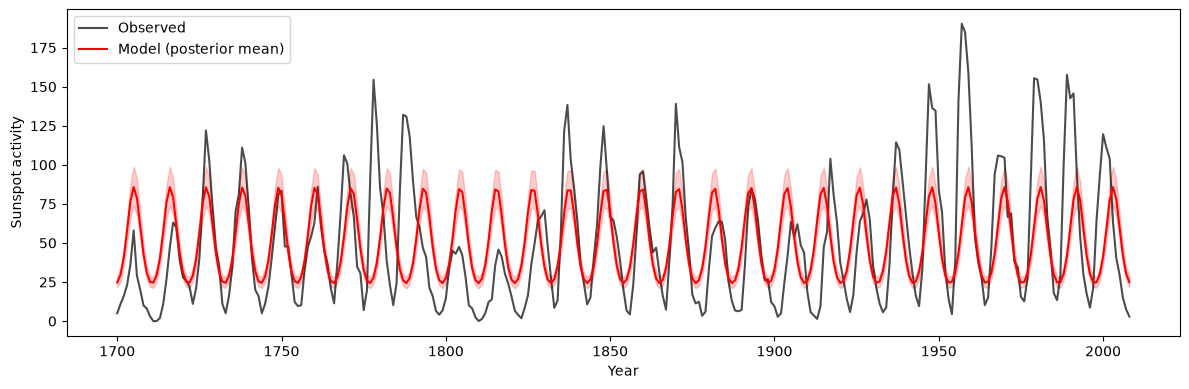

In [59]:

log_signal_post = (
    trace_sunspot_v3.posterior["mu"].values.reshape(-1, 1)
    + trace_sunspot_v3.posterior["beta1"].values.reshape(-1, 1) * np.sin(omega * t)
    + trace_sunspot_v3.posterior["beta2"].values.reshape(-1, 1) * np.cos(omega * t)
)
mean_signal_post = np.exp(log_signal_post)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(year, activity, color="black", label="Observed", alpha=0.7)
ax.plot(year, mean_signal_post.mean(axis=0), color="red", label="Model (posterior mean)")
ax.fill_between(
    year,
    np.percentile(mean_signal_post, 5.5, axis=0),
    np.percentile(mean_signal_post, 94.5, axis=0),
    color="red", alpha=0.2
)
ax.set_xlabel("Year")
ax.set_ylabel("Sunspot activity")
ax.legend()
plt.tight_layout()
plt.show()

In [64]:
with pm.Model() as model_sunspot_v4:
    mu = pm.Normal("mu", mu=np.log(activity.mean() + 1), sigma=1)
    sigma_beta = pm.HalfNormal("sigma_beta", sigma=0.1)
    beta1 = pm.GaussianRandomWalk("beta1_t", sigma=sigma_beta, init_dist=pm.Normal.dist(0, 1), steps=n-1)
    beta2 = pm.GaussianRandomWalk("beta2_t", sigma=sigma_beta, init_dist=pm.Normal.dist(0, 1), steps=n-1)
    
    # 対数スケールでの平均構造 → exp で正の値に変換
    log_mean_signal = mu + beta1 * pm.math.sin(omega * t) + beta2 * pm.math.cos(omega * t)
    mean_signal = pm.math.exp(log_mean_signal)
    
    # 観測ノイズ:正の連続値なのでGammaを使う(TruncatedNormalより自然)
    # Gammaはmu(平均)とsigma(標準偏差)で指定できる
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=1)
    
    obs = pm.Gamma("obs", mu=mean_signal, sigma=sigma_obs * mean_signal, observed=activity + 1e-5)
    
    trace_sunspot_v4 = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Rewrite failure due to: local_subtensor_merge_slice
node: Subtensor{i}(Subtensor{start:stop}.0, 0)
TRACEBACK:
Traceback (most recent call last):
  File "/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pytensor/graph/rewriting/basic.py", line 1920, in process_node
    replacements = node_rewriter.transform(
                   ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pytensor/graph/rewriting/basic.py", line 993, in transform
    return self.fn(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pytensor/tensor/rewriting/subtensor.py", line 973, in local_subtensor_merge_slice
    return _local_subtensor_merge_rewrite(fgraph, node, merge_integer_index=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/manaty/markov-regime-switching/.

/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 60 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [66]:
az.summary(trace_sunspot_v4, var_names=["mu", "beta1_t", "beta2_t", "sigma_obs"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,3.68,0.0473,3.6,3.8,4686,5853,1.00,0.00069,0.00049
beta1_t[0],-0.177,0.398,-0.81,0.47,9170,7098,1.00,0.0042,0.0029
beta1_t[1],-0.18,0.383,-0.78,0.44,9177,6664,1.00,0.004,0.0028
beta1_t[2],-0.18,0.372,-0.77,0.42,9119,6822,1.00,0.0039,0.0028
beta1_t[3],-0.174,0.363,-0.74,0.41,9207,6950,1.00,0.0038,0.0027
...,...,...,...,...,...,...,...,...,...
beta2_t[305],-0.457,0.317,-0.97,0.042,11138,6843,1.00,0.003,0.0021
beta2_t[306],-0.476,0.339,-1,0.056,10765,6379,1.00,0.0033,0.0023
beta2_t[307],-0.497,0.356,-1.1,0.067,10656,7082,1.00,0.0035,0.0025
beta2_t[308],-0.513,0.375,-1.1,0.077,11117,7025,1.00,0.0036,0.0026


(4, 2000, 309)


/tmp/ipykernel_43452/208335842.py:14: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43452/208335842.py:14: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43452/208335842.py:14: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43452/208335842.py:14: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43452/208335842.py:14: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43452/208335842.py:14: UserWarning: Glyph 12427 (\N{HIRAGANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43452/208335842.py:14: UserWarning: Glyph 25391 (\N{CJK UNIFIED IDEOGRAPH-632F}) missing from f

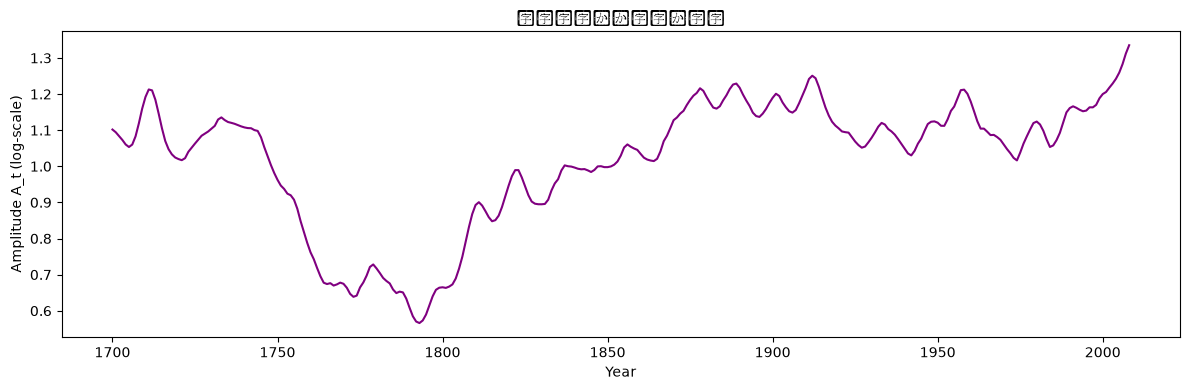

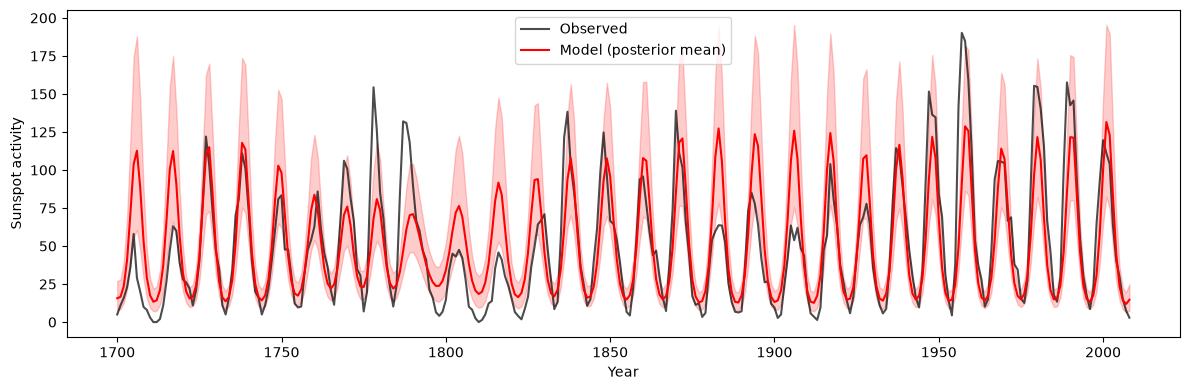

In [73]:
beta1_samples = trace_sunspot_v4.posterior["beta1_t"].values
beta2_samples = trace_sunspot_v4.posterior["beta2_t"].values

print(beta1_samples.shape)

A_t_samples = np.sqrt(beta1_samples**2 +  beta2_samples**2)
A_t_mean = A_t_samples.reshape(-1, n).mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(year, A_t_mean, color="purple")
ax.set_xlabel("Year")
ax.set_ylabel("Amplitude A_t (log-scale)")
ax.set_title("時間変化する振幅の推定")
plt.tight_layout()
plt.show()

mu_samples = trace_sunspot_v4.posterior["mu"].values.reshape(-1, 1)
log_mean_post = (
    mu_samples
    + beta1_samples.reshape(-1, n) * np.sin(omega * t)
    + beta2_samples.reshape(-1, n) * np.cos(omega * t)
)
mean_signal_post = np.exp(log_mean_post)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(year, activity, color="black", label="Observed", alpha=0.7)
ax.plot(year, mean_signal_post.mean(axis=0), color="red", label="Model (posterior mean)")
ax.fill_between(
    year,
    np.percentile(mean_signal_post, 5.5, axis=0),
    np.percentile(mean_signal_post, 94.5, axis=0),
    color="red", alpha=0.2
)
ax.set_xlabel("Year")
ax.set_ylabel("Sunspot activity")
ax.legend()
plt.tight_layout()
plt.show()

In [77]:
az.summary(trace_sunspot_v4, var_names=[ "sigma_beta"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_beta,0.121,0.024,0.086,0.16,85,181,1.02,0.0025,0.0018


In [76]:
trace_sunspot_v4.sample_stats.diverging.sum().item()

0

In [79]:
summary_full = az.summary(trace_sunspot_v4, var_names=["beta1_t", "beta2_t"])
print("r_hat の最大値:", summary_full["r_hat"].max())
print("ess_bulk の最小値:", summary_full["ess_bulk"].min())



r_hat の最大値: 1.00
ess_bulk の最小値: 377


In [82]:
with pm.Model() as model_sunspot_v5:
    mu = pm.Normal("mu", mu=np.log(activity.mean() + 1), sigma=1)
    sigma_beta = pm.HalfNormal("sigma_beta", sigma=0.1)
    beta1_1 = pm.GaussianRandomWalk("beta1_1_t", sigma=sigma_beta, init_dist=pm.Normal.dist(0, 1), steps=n-1)
    beta2_1 = pm.GaussianRandomWalk("beta2_1_t", sigma=sigma_beta, init_dist=pm.Normal.dist(0, 1), steps=n-1)


    beta1_2 = pm.Normal("beta1_2", mu=0, sigma=0.5)
    beta2_2 = pm.Normal("beta2_2", mu=0, sigma=0.5)
    
    # 対数スケールでの平均構造 → exp で正の値に変換
    log_mean_signal = (
        mu 
        + beta1_1 * pm.math.sin(omega * t) + beta2_1 * pm.math.cos(omega * t)
        + beta1_2 * pm.math.sin(2 * omega * t) + beta2_1 * pm.math.cos(2 * omega * t)
    )
    mean_signal = pm.math.exp(log_mean_signal)
    
    # 観測ノイズ:正の連続値なのでGammaを使う(TruncatedNormalより自然)
    # Gammaはmu(平均)とsigma(標準偏差)で指定できる
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=1)
    
    obs = pm.Gamma("obs", mu=mean_signal, sigma=sigma_obs * mean_signal, observed=activity + 1e-5)
    
    trace_sunspot_v5 = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Rewrite failure due to: local_subtensor_merge_slice
node: Subtensor{i}(Subtensor{start:stop}.0, 0)
TRACEBACK:
Traceback (most recent call last):
  File "/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pytensor/graph/rewriting/basic.py", line 1920, in process_node
    replacements = node_rewriter.transform(
                   ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pytensor/graph/rewriting/basic.py", line 993, in transform
    return self.fn(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pytensor/tensor/rewriting/subtensor.py", line 973, in local_subtensor_merge_slice
    return _local_subtensor_merge_rewrite(fgraph, node, merge_integer_index=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/manaty/markov-regime-switching/.

/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 88 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [84]:
az.summary(trace_sunspot_v5, var_names=["mu", "beta1_2", "beta2_2", "sigma_beta", "sigma_obs"])



,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,3.772,0.0513,3.7,3.9,7912,5584,1.00,0.00058,0.00041
beta1_2,-0.071,0.072,-0.18,0.046,8000,5062,1.00,0.00081,0.00058
beta2_2,-0.01,0.5,-0.81,0.79,7739,4981,1.00,0.0057,0.004
sigma_beta,0.086,0.016,0.062,0.11,93,174,1.04,0.0016,0.0013
sigma_obs,0.8535,0.0321,0.8,0.91,6726,5320,1.00,0.00039,0.00028


In [85]:
n_div = trace_sunspot_v5.sample_stats.diverging.sum().item()
print(f"Divergences: {n_div}")

Divergences: 0


In [88]:
summary_full = az.summary(trace_sunspot_v5, var_names=["beta1_1_t", "beta2_1_t"])
print("r_hat の最大値:", summary_full["r_hat"].max())
print("ess_bulk の最小値:", summary_full["ess_bulk"].min())
print("ess_tail の最小値:", summary_full["ess_tail"].min())

r_hat の最大値: 1.01
ess_bulk の最小値: 565
ess_tail の最小値: 1722


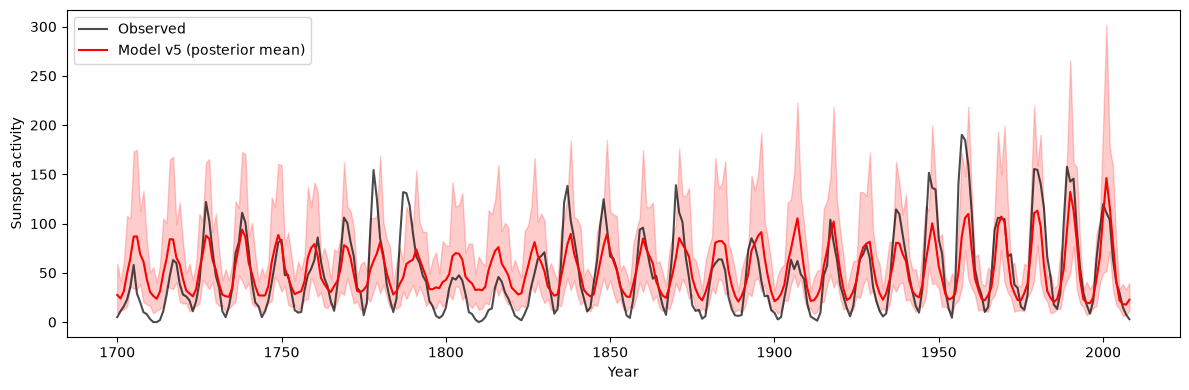

In [86]:
beta1_1_samples = trace_sunspot_v5.posterior["beta1_1_t"].values.reshape(-1, n)
beta2_1_samples = trace_sunspot_v5.posterior["beta2_1_t"].values.reshape(-1, n)
beta1_2_samples = trace_sunspot_v5.posterior["beta1_2"].values.reshape(-1, 1)
beta2_2_samples = trace_sunspot_v5.posterior["beta2_2"].values.reshape(-1, 1)
mu_samples = trace_sunspot_v5.posterior["mu"].values.reshape(-1, 1)

log_mean_post = (
    mu_samples
    + beta1_1_samples * np.sin(omega * t) + beta2_1_samples * np.cos(omega * t)
    + beta1_2_samples * np.sin(2 * omega * t) + beta2_2_samples * np.cos(2 * omega * t)
)
mean_signal_post = np.exp(log_mean_post)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(year, activity, color="black", label="Observed", alpha=0.7)
ax.plot(year, mean_signal_post.mean(axis=0), color="red", label="Model v5 (posterior mean)")
ax.fill_between(
    year,
    np.percentile(mean_signal_post, 5.5, axis=0),
    np.percentile(mean_signal_post, 94.5, axis=0),
    color="red", alpha=0.2
)
ax.set_xlabel("Year")
ax.set_ylabel("Sunspot activity")
ax.legend()
plt.tight_layout()
plt.show()

# 太陽黒点数モデリング:周期性を持つ非線形状態空間モデルの診断と学び
 
## 概要
 
太陽黒点数データ(`sunspot.year`、1700〜2008年、n=309)に対して、約11年周期の変動を捉える調和回帰(harmonic regression)ベースの状態空間モデルをPyMCで構築し、段階的に改善しながら診断を行った過程の記録。前回のLynx個体群動態モデリングで得た教訓(サンプリング健全性とモデル表現力の切り分け)を、今回は最初から設計に活かすことを意識した。
 
---
 
## 1. 極形式パラメータ化がもたらす多峰性(Multimodality)
 
### 最初のモデル
```
x_t = mu + A * sin(2*pi*t/T + phi) + noise
```
振幅`A`・周期`T`・位相`phi`を直接推定する「極形式(polar form)」から出発。
 
### 問題の発生
Divergences=0にもかかわらず、`T`のr_hat=2.10、`phi`のr_hat=1.91という深刻な収束の失敗が発生。Trace plotを見ると、**4本のchainがそれぞれ全く異なる`T`の値(10.1, 10.5, 11.0など)に固定されたまま、一切混ざっていない**ことが判明。
 
### 原因の特定
`sin(2π·t/T + φ)`という極形式は、`T`と`φ`の間に強い非線形的な相互作用を生む。周期がわずかに違うだけで、長い時系列全体(t=0〜308)にわたって位相が大きくズレていくため、尤度面に複数の「谷」(局所解)ができる。各chainはそれぞれ別の谷に落ちて、そこから出られなくなる。
 
> **学び①**: Divergence=0は「局所的にはサンプラーがうまく動けている」ことしか意味しない。谷と谷の間の壁を飛び越えられずにchainが別々の局所解に閉じ込められる"マルチモーダリティ"は、r_hatという大域的な指標でしか検出できない。周期・位相を持つパラメータは特にこの問題を起こしやすい。
 
### 試して効果がなかった対策
`T`の事前分布を`Normal(mu=11, sigma=2)`から`Normal(mu=11, sigma=0.3)`へ絞ったが、r_hatはむしろ2.41に悪化。**事前分布を締めても、パラメータ化自体が生む尤度面の複雑な形状(局所解の存在)は解消されない**ことが確認された(Lynxのsigma_obsのケースと同種の教訓)。
 
---
 
## 2. 直交形式への再パラメータ化で多峰性を解消
 
### 解決策
振幅・位相形式を、線形結合の「直交形式(Cartesian form)」に書き換える:
```
A*sin(ωt+φ) = β1*sin(ωt) + β2*cos(ωt)
```
`ω = 2π/T`は周期図(periodogram)から得た値で固定し、`β1`, `β2`を通常の線形パラメータとして推定。振幅・位相は事後的に`Deterministic`として復元(`A=sqrt(β1²+β2²)`, `φ=atan2(β2,β1)`)。
 
### 結果
全パラメータでr_hat=1.00、ess_bulkは数千に到達。多峰性は完全に解消された。
 
> **学び②**: パラメータが三角関数の"中"(周波数・位相)に入っていると、範囲を絞っても多峰性が残ることがある。三角関数の"外"にある線形係数として書き直す(直交形式化)ことで、モデルの表現力を保ったまま尤度面を滑らかにできる。周期を推定対象から外し外生的に固定するという設計判断も、多峰性の根本原因(T-φ間の相互作用)を排除する上で有効だった。
 
---
 
## 3. 固定振幅モデルの限界:非負制約と時間不変振幅の問題
 
直交形式で健全な収束を得た後、モデルフィットを可視化すると2つの構造的な問題が明らかになった:
 
1. **谷が負の値を取る**: `mu + A*sin(...)` という線形の平均構造は理論上負になりうるが、黒点数は本来非負
2. **振幅が時間一定**: ダルトン極小期(1800年頃)や1950年代の突出したピークなど、実データの振幅変動を全く再現できない
これはLynxのときと同じ構図(サンプリングは健全だが、決定論的なforward simulationでモデルの表現力の限界が可視化される)であり、**「サンプリングの成功」と「現象の説明力」は別問題**という前回の学びがそのまま再現された。
 
---
 
## 4. 対数リンク関数 + Gamma分布による非負制約の解消
 
### 変更内容
```python
log_mean_signal = mu + β1*sin(ωt) + β2*cos(ωt)
mean_signal = exp(log_mean_signal)
obs ~ Gamma(mu=mean_signal, sigma=sigma_obs * mean_signal)
```
平均構造自体を対数スケールにし、`exp`で正の値に変換。観測分布もTruncatedNormalから、正の連続値に自然な`Gamma`分布(分散が平均に比例)に変更。
 
### 結果
谷が0近くに自然に留まるようになり、非対称な波形(山は尖り、谷はなだらか)が構造から自然に生まれた。ただし振幅の時間変化は未対応のため、1950年代の大ピークなどにはまだ追従できていない。
 
> **学び③**: 非負制約は観測分布(尤度)側だけでなく、平均構造(リンク関数)自体に組み込むことで、より自然な非対称性が得られる。改善は一度に複数点行わず、1つずつ変更して効果を切り分けることで、「何が効いたか」を正確に特定できる。
 
---
 
## 5. GaussianRandomWalkによる振幅の時間変化の導入
 
### 実装上のつまずき:OverflowError
```python
beta1 = pm.GaussianRandomWalk("beta1_t", sigma=sigma_beta, shape=n)
# → OverflowError: Python integer 311 out of bounds for int8
```
`shape`引数から内部でステップ数を逆算する処理が`int8`にキャストされる実装上の癖により、`n`が127を超えるとオーバーフローする。
 
**対策**: `shape`ではなく`steps`と`init_dist`を明示的に指定する。
```python
beta1 = pm.GaussianRandomWalk(
    "beta1_t", sigma=sigma_beta,
    init_dist=pm.Normal.dist(0, 1), steps=n-1
)
```
 
### 結果
`β1_t`, `β2_t`(計618個のパラメータ)すべてでr_hat≤1.01、ess_bulk≥377という非常に健全な収束を達成。振幅`A_t = sqrt(β1_t² + β2_t²)`の時系列を可視化すると、ダルトン極小期での振幅低下、1950年代・2000年代での振幅増大が明確に捉えられた。
 
> **学び④**: 大量の時変パラメータ(600個超)を含むモデルでも、直交形式のような滑らかなパラメータ化を保っていれば、サンプリングは健全に機能する。パラメータ数の多さそのものは収束の障害にならない。
 
---
 
## 6. 高調波(2次調和成分)の追加とその限界
 
### 動機
振幅は時間変化するようになったが、山の非対称性(急な立ち上がり・緩やかな減衰)と谷の深さがまだ実データほど再現できていなかった。フーリエ級数の考え方で2次高調波(2ω成分)を追加。
 
```python
log_mean_signal = mu + β1_1*sin(ωt) + β2_1*cos(ωt) + β1_2*sin(2ωt) + β2_2*cos(2ωt)
```
まずは2次高調波の振幅は固定(時間変化なし)としてシンプルに導入。
 
### 結果と評価
- サンプリングは健全(r_hat≤1.01、Divergences=0)
- しかし`β1_2`, `β2_2`の事後分布は事前分布とほぼ同じ広さで、信用区間が0をまたぐ → **データから2次高調波の存在を強く支持する証拠は得られなかった**
- フィットの可視化では、波形にわずかな非対称性は見られたが、劇的な改善ではなかった
- **新たな問題**: 予測の信用区間(不確実性の帯)が時系列の終端(2000年代)に近づくほど急激に広がった
### 不確実性が終端で肥大化する理由
`GaussianRandomWalk`は「平均に回帰する力」を持たない過程であるため、時点が進むほど累積的な不確実性が増加するという数学的な構造上の性質を持つ。太陽黒点周期の"強さ"が実際に無限に発散するわけではないのに、モデル構造がそれを許容してしまっている。
 
> **学び⑤**: モデル拡張(高調波の追加)は必ずしも改善に直結するとは限らず、パラメータの事後分布(信用区間が0をまたぐか)を確認することで「本当にデータが支持しているか」を検証する必要がある。また、ランダムウォークで時間変化を表現する場合、mean-revertingでない性質が終端の不確実性肥大化という副作用を生むことがあり、物理的に妥当な代替(OU過程やAR(1)的な減衰項)を検討する余地がある。
 
---
 
## 最終的な到達点
 
| 段階 | 主な変更 | r_hat/ess | フィットの特徴 |
|---|---|---|---|
| v0: 極形式(振幅・周期・位相直接推定) | - | T,phi で r_hat > 2 (多峰性) | 未評価 |
| v1: 周期図で事前分布を絞る | Tの事前分布をタイトに | 悪化(r_hat=2.41) | 未評価 |
| v2: 直交形式化 + 周期固定 | β1,β2の線形パラメータ化 | 全てr_hat=1.00 | 振幅一定、谷が負値 |
| v3: 対数リンク+Gamma分布 | 非負制約を平均構造に組込み | 健全 | 谷は改善、振幅一定のまま |
| v4: GaussianRandomWalkで振幅を時変に | steps/init_distで実装 | 全618個 r_hat≤1.01 | 振幅の時間変化を捕捉 |
| v5: 2次高調波追加 | 固定振幅の2ω成分 | 健全(Divergences=0) | 改善は限定的、終端の不確実性肥大化 |
 
---
 
## 診断プロセスのフローまとめ
 
```
極形式モデル(T, φ直接推定)
    │
    ├─ Divergence=0だがr_hat>2(マルチモーダリティ発見)
    │   └─ 事前分布を絞っても悪化(パラメータ化自体が原因と判明)
    │
    ├─ 周期図(periodogram)でデータから周期を特定
    │
    ├─ 直交形式へ再パラメータ化(β1, β2線形化)+ 周期固定
    │   └─ 全パラメータ r_hat=1.00 に到達
    │
    ├─ Forward simulation的なフィット可視化
    │   └─ 谷が負値・振幅時間不変という構造的限界を発見
    │
    ├─ 対数リンク + Gamma分布 → 非負制約を解決
    │
    ├─ GaussianRandomWalkで振幅を時変化
    │   └─ 実装エラー(int8 overflow)→ steps/init_distで解決
    │   └─ 振幅の時代変化(ダルトン極小期等)を捕捉
    │
    └─ 2次高調波を追加
        └─ サンプリングは健全だが、係数の信用区間が0をまたぎ効果は限定的
        └─ ランダムウォークの構造的性質による終端の不確実性肥大化を発見
```
 
## 汎用的な教訓(Lynxからの継承 + 今回新たに得たもの)
 
1. **Divergence=0は万能の合格証ではない** — マルチモーダリティはr_hatでしか検出できないことがある(継承+深化)
2. **事前分布を締めても、パラメータ化自体が生む病理は解消されない** — 極形式→直交形式のような構造変更が必要な場合がある(継承+新事例)
3. **周期性を持つパラメータ(周波数・位相)は特に多峰性を生みやすい** — 直交形式(線形結合)への変換が有効な対策(今回新規)
4. **改善は1点ずつ、効果を切り分けながら進める** — 非負制約と振幅時間変化を同時に扱わず、段階的に導入したことで各変更の効果が明確になった(継承)
5. **モデル拡張の効果は、パラメータの信用区間で検証する** — 高調波を追加しても、係数の信用区間が0をまたげば「データが支持していない」と判断できる(今回新規)
6. **時間変化パラメータの表現方法自体が新たな構造的副作用を生むことがある** — GaussianRandomWalkの非mean-reverting性による終端の不確実性肥大化(今回新規、今後の課題)
 
